A = 0.48282986465771804
T = 14.074270157233315


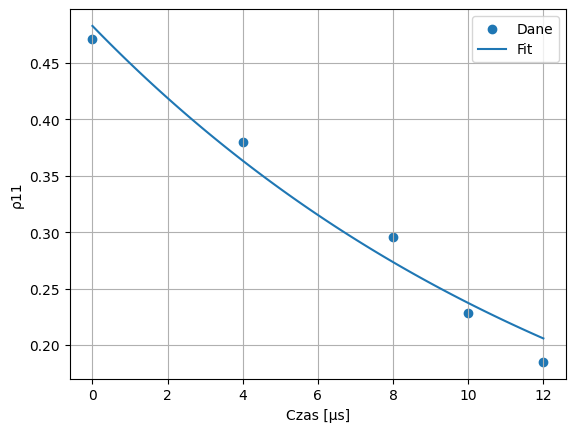

In [1]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# przykładowe dane
xdata = np.array([0, 4, 8, 10, 12])
ydata = np.array([0.471, 0.38, 0.296, 0.228, 0.185])

def decay(x, T, A):
    return A*np.exp(-x/T)

params, covariance = curve_fit(
    decay,
    xdata,
    ydata,
    p0=[10, 1],        # ważne!
    #bounds=(
    #[-np.inf, 0, 1, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf],   # p >= 0
    #[np.inf, np.inf, 2, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]   # p <= 10
    #),
    maxfev=10000
)

T, A = params
print("A =", A)
print("T =", T)

x_fit = np.linspace(min(xdata), max(xdata), 100)
y_fit = decay(x_fit, T, A)

plt.scatter(xdata, ydata, label='Dane')
plt.plot(x_fit, y_fit, label='Fit')

plt.xlabel("Czas [µs]")
plt.ylabel("ρ11")
plt.legend()
plt.grid(True)
plt.show()